# Lab 4: Model-Based Deep RL

## TDDE78 — Deep Reinforcement Learning
**Linköping University, Spring 2026**

---

This lab covers two model-based RL approaches:

- **Dyna-Q**: augments DQN with a learned neural dynamics model for simulated planning
- **MCTS (UCT)**: uses tree search with environment simulations to select actions

Both methods are evaluated on **CliffWalking-v1** — a 4×12 gridworld where the agent
navigates from start to goal while avoiding a cliff.

> **Note:** The DQN components (Q-network, replay buffer, ε-greedy, Q-update) are already implemented and provided. Your tasks are to implement the **WorldModel** (in `networks.py`) and the **MCTSPlanner**.

In [3]:
import os
import copy
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from networks import QNetwork, WorldModel
from utils import ReplayBuffer, plot_dyna_results, plot_comparison, smooth, _save_plot

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

_here = globals().get('__vsc_ipynb_file__', os.path.abspath(''))
_nb_dir = os.path.dirname(_here) if os.path.isfile(_here) else _here
EXPERIMENTS_DIR = os.path.normpath(os.path.join(_nb_dir, '..', 'experiments'))
print(f'Experiments directory: {EXPERIMENTS_DIR}')

ENV_NAME  = 'CliffWalking-v1'
N_STATES  = 48   # 4 x 12 grid
N_ACTIONS = 4

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

def obs_to_onehot(obs, n_states=N_STATES):
    """Convert a discrete integer observation to a one-hot float vector."""
    v = np.zeros(n_states, dtype=np.float32)
    v[int(obs)] = 1.0
    return v

set_seed(42)
print('Setup complete!')

Using device: cuda
Experiments directory: /home/arviv790/Code/LiU/tdde78/labs/lab4_model_based/experiments
Setup complete!


---

## A.1 — Explore the Environment

**CliffWalking-v1** is a 4×12 gridworld:
- **Start**: bottom-left (state 36)
- **Goal**: bottom-right (state 47)
- **Cliff**: bottom row between start and goal (states 37–46, reward −100)
- **Reward**: −1 per step, −100 for falling off cliff (reset to start)
- **Solved**: optimal path reward ≈ −13 (go around the top)

The agent has no knowledge of these dynamics — it learns the world model from scratch.

In [4]:
env = gym.make(ENV_NAME)
print(f'Observation space: {env.observation_space}  (integer state 0–{N_STATES-1})')
print(f'Action space:      {env.action_space}  (0=up, 1=right, 2=down, 3=left)')

obs, _ = env.reset(seed=42)
total, steps = 0, 0
for _ in range(200):
    obs, r, term, trunc, _ = env.step(env.action_space.sample())
    total += r; steps += 1
    if term or trunc: break
print(f'\nRandom agent — steps: {steps}, total reward: {total:.1f}')
print(f'One-hot encoding example: obs={int(obs)} → shape {obs_to_onehot(obs).shape}')
env.close()

Observation space: Discrete(48)  (integer state 0–47)
Action space:      Discrete(4)  (0=up, 1=right, 2=down, 3=left)

Random agent — steps: 200, total reward: -2675.0
One-hot encoding example: obs=27 → shape (48,)


---

# Part A — Implementation

---

## DynaAgent (provided skeleton)

> **DQN is reused from Lab 1** — the Q-network, target network, replay buffer, and ε-greedy policy are already implemented in `DynaAgent` below. You do **not** re-implement DQN here.

The new component is the **WorldModel** (in `networks.py`): a neural network trained with supervised learning to predict **next-state logits** (cross-entropy loss), **reward** (MSE loss), and **done** (BCE loss) from (one-hot state, one-hot action).

For discrete environments, the WorldModel outputs **logits over all states** rather than a continuous vector.  During planning the next state is sampled from this learned distribution.

**Key design choice:** Planning only starts after `model_warm_start` real transitions have been collected — this prevents a poorly-fitted model from corrupting the Q-function before it has reliable predictions.

In [ ]:
class DynaAgent:
    """
    Dyna-Q agent: DQN (provided, Lab 1) + WorldModel + simulated planning.

    States are one-hot encoded before storage in the replay buffer.
    The WorldModel predicts next-state logits (cross-entropy) rather than Δs.

    The DQN components are fully provided. Your tasks are:
      1. Implement WorldModel in networks.py
      2. Implement _model_update() below
      3. Implement the planning loop in update()

    Args:
        state_dim        (int):   n_states  (one-hot dimension).
        action_dim       (int):   n_actions.
        lr               (float): Learning rate for Q-network and world model.
        gamma            (float): Discount factor.
        buffer_capacity  (int):   Replay buffer size.
        batch_size       (int):   Mini-batch size.
        planning_steps   (int):   Simulated Q-updates per real step (0 = pure DQN).
        model_warm_start (int):   Real transitions before planning begins.
        target_update    (int):   Hard target-network update frequency (steps).
        max_grad_norm    (float): Gradient clipping for Q-network.
        eps_start        (float): Initial ε for ε-greedy exploration.
        eps_end          (float): Final ε.
        eps_decay        (float): Multiplicative ε decay per episode.
    """

    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99,
                 buffer_capacity=20_000, batch_size=64, planning_steps=10,
                 model_warm_start=500, target_update=100, max_grad_norm=10.0,
                 eps_start=1.0, eps_end=0.05, eps_decay=0.99, seed=42):
        self.state_dim        = state_dim
        self.action_dim       = action_dim
        self.gamma            = gamma
        self.batch_size       = batch_size
        self.planning_steps   = planning_steps
        self.model_warm_start = model_warm_start
        self.target_update    = target_update
        self.max_grad_norm    = max_grad_norm
        self.epsilon          = eps_start
        self.eps_end          = eps_end
        self.eps_decay        = eps_decay
        self._step            = 0

        # ── DQN (reused from Lab 1) ──────────────────────────────────
        self.q_net      = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.buffer     = ReplayBuffer(buffer_capacity, state_dim)
        self.q_opt      = torch.optim.Adam(self.q_net.parameters(), lr=lr)

        # ── WorldModel (new — implement in networks.py) ──────────────
        self.world_model = WorldModel(state_dim, action_dim).to(device)
        self.model_opt   = torch.optim.Adam(self.world_model.parameters(), lr=lr)

    # ── Provided: ε-greedy action selection ──────────────────────────
    def select_action(self, state_onehot):
        """ε-greedy action selection on a one-hot encoded state."""
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.action_dim)
        state_t = torch.FloatTensor(state_onehot).unsqueeze(0).to(device)
        with torch.no_grad():
            return self.q_net(state_t).argmax().item()

    # ── Provided: DQN Q-update ────────────────────────────────────────
    def _q_update(self, states, actions, rewards, next_states, dones):
        """One DQN gradient step with gradient clipping."""
        with torch.no_grad():
            next_q  = self.target_net(next_states).max(dim=1).values
            targets = rewards + self.gamma * (1.0 - dones) * next_q
        q_vals = self.q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        loss   = F.mse_loss(q_vals, targets)
        self.q_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q_net.parameters(), self.max_grad_norm)
        self.q_opt.step()
        self._step += 1
        if self._step % self.target_update == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())
        return loss.item()

    # ── TODO: WorldModel supervised update ───────────────────────────
    def _model_update(self, states, actions, rewards, next_states, dones):
        """
        Train the WorldModel on one batch of real transitions.

        Convert actions to one-hot, run the world model forward, then compute
        three losses: cross-entropy for next state, MSE for reward, and
        binary cross-entropy for the done signal. Backprop and return the
        combined loss value.
        """
        #One-hot conversion
        actions_onehot = F.one_hot(actions, num_classes=self.action_dim).float() #We cast actions to float because WorldModel expects it 
        
        #Run world model forward
        next_state, reward, done_logit = self.world_model(states, actions_onehot)
        
        #Predicted state we're going to end up in according to WorldModel
        next_state_i = next_states.argmax(dim=1)
        
        #Compute losses
        loss_next_state = F.cross_entropy(next_state, next_state_i)
        loss_reward = F.mse_loss(reward, rewards)
        loss_done = F.binary_cross_entropy_with_logits(done_logit, dones)
        
        #Backprop and return of total loss
        total_loss = loss_next_state + loss_reward + loss_done
        self.model_opt.zero_grad()
        total_loss.backward()
        self.model_opt.step()
        
        return total_loss.item()
        

    # ── TODO: Full Dyna update (real Q-step + model train + planning) ─
    def update(self):
        """
        Full Dyna update — return (0.0, 0.0) if the buffer is not ready yet.

        1. Sample a real batch and perform a Q-update and a model update.
        2. Planning loop (only after model_warm_start real transitions):
           repeat planning_steps times — sample states from the buffer,
           query the world model to generate synthetic transitions, then
           run a Q-update on those simulated transitions.
        3. Return (q_loss, model_loss).
        """
        #Return (0.0, 0.0) if buffer not ready
        if len(self.buffer) < self.batch_size:
            return (0.0, 0.0)
        
        #Sample real batch
        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)
        
        #Move stuff to device
        states = states.to(device)
        actions = actions.to(device)
        rewards = rewards.to(device)
        next_states = next_states.to(device)
        dones = dones.to(device)
        
        #Perform Q-update and model update
        q_loss = self._q_update(states, actions, rewards, next_states, dones)
        model_loss = self._model_update(states, actions, rewards, next_states, dones)
        
        if len(self.buffer) >= self.model_warm_start: #Only real transitions stored in the buffer
            #Planning loop
            for _ in range(self.planning_steps):
                #Sample single random (state, action) pair
                state_sim, action_sim, _, _, _ = self.buffer.sample(1)
                
                #Move stuff to device
                state_sim = state_sim.to(device)
                action_sim = action_sim.to(device)
                
                with torch.no_grad():
                    #One-hot encode actions and generate synthetic transition
                    action_onehot = F.one_hot(action_sim, num_classes=self.action_dim).float() #We cast actions to float because WorldModel expects it
                    next_state_sim, reward_sim, done_sim = self.world_model(state_sim, action_onehot)
                    
                    #Predicted state we're going to end up in according to WorldModel
                    next_state_i = next_state_sim.argmax(dim=1)
                    
                    #One-hot encode states
                    next_state_sim = F.one_hot(next_state_i, num_classes=self.state_dim).float() #We cast states to float because Q-network expects it
                    
                    #Sigmoid to convert logits to probability, necessary because (1 - dones) is done in _q_update()
                    done_sim = torch.sigmoid(done_sim)
                
                #Run Q-update on simulated transitions
                self._q_update(state_sim, action_sim, reward_sim, next_state_sim, done_sim)
                
        return q_loss, model_loss
        

print('DynaAgent defined')

DynaAgent defined


In [6]:
def train_dyna(env_name=ENV_NAME, total_timesteps=50_000,
               planning_steps=10, seed=42, solve_threshold=-14.0,
               log_interval=50, **agent_kwargs):
    """
    Train a DynaAgent on CliffWalking-v1.

    With planning_steps=0 this is equivalent to a standard DQN (baseline).

    Args:
        env_name        (str):   Gymnasium environment id.
        total_timesteps (int):   Maximum environment steps.
        planning_steps  (int):   Simulated updates per real step.
        seed            (int):   Random seed.
        solve_threshold (float): Early-stop when avg reward (last 50 ep) >= this.
        log_interval    (int):   Print every N episodes.
        **agent_kwargs:          Passed to DynaAgent.

    Returns:
        dict with keys: episode_rewards, episode_timesteps, q_losses, model_losses, agent
    """
    set_seed(seed)
    # max_episode_steps=200 guarantees truncation; some Gymnasium builds of
    # CliffWalking-v1 omit the TimeLimit wrapper, leaving episodes open-ended.
    env       = gym.make(env_name, max_episode_steps=200)
    n_states  = env.observation_space.n
    n_actions = env.action_space.n

    agent = DynaAgent(n_states, n_actions,
                      planning_steps=planning_steps, seed=seed, **agent_kwargs)

    episode_rewards   = []
    episode_timesteps = []
    q_losses          = []
    model_losses      = []

    raw_obs, _ = env.reset(seed=seed)
    obs        = obs_to_onehot(raw_obs, n_states)
    ep_reward  = 0.0

    for step in range(total_timesteps):
        action                           = agent.select_action(obs)
        next_raw, reward, term, trunc, _ = env.step(action)
        done                             = term or trunc
        next_obs                         = obs_to_onehot(next_raw, n_states)

        agent.buffer.push(obs, action, reward, next_obs, float(term))
        ep_reward += reward
        obs = next_obs

        if done:
            episode_rewards.append(ep_reward)
            episode_timesteps.append(step + 1)
            ep_reward  = 0.0
            raw_obs, _ = env.reset()
            obs        = obs_to_onehot(raw_obs, n_states)
            agent.epsilon = max(agent.eps_end, agent.epsilon * agent.eps_decay)

            n = len(episode_rewards)
            if n % log_interval == 0:
                avg = np.mean(episode_rewards[-log_interval:])
                print(f'Step {step+1:>6,} | Episode {n:4d} | '
                      f'Avg({log_interval}): {avg:6.1f} | eps: {agent.epsilon:.3f}')

            if solve_threshold and n >= 50:
                if np.mean(episode_rewards[-50:]) >= solve_threshold:
                    print(f'Solved at step {step+1:,}!')
                    break

        q_loss, m_loss = agent.update()
        q_losses.append(q_loss)
        model_losses.append(m_loss)

    env.close()
    return {
        'episode_rewards':   episode_rewards,
        'episode_timesteps': episode_timesteps,
        'q_losses':          q_losses,
        'model_losses':      model_losses,
        'agent':             agent,
    }

print('train_dyna defined')

train_dyna defined


## A.2 — Train Dyna on CliffWalking-v1

Train DynaAgent with `planning_steps=10`. The solve threshold is −14
(optimal path reward ≈ −13). Compare against the DQN baseline (`planning_steps=0`).

Step  8,523 | Episode   50 | Avg(50): -1663.4 | eps: 0.605
Step 11,285 | Episode  100 | Avg(50): -364.1 | eps: 0.366
Step 12,796 | Episode  150 | Avg(50): -160.9 | eps: 0.221
Step 13,853 | Episode  200 | Avg(50):  -90.4 | eps: 0.134
Step 14,770 | Episode  250 | Avg(50):  -59.9 | eps: 0.081
Step 15,581 | Episode  300 | Avg(50):  -40.0 | eps: 0.050
Step 16,320 | Episode  350 | Avg(50):  -24.7 | eps: 0.050
Step 17,064 | Episode  400 | Avg(50):  -22.8 | eps: 0.050
Step 17,855 | Episode  450 | Avg(50):  -41.6 | eps: 0.050
Step 18,581 | Episode  500 | Avg(50):  -24.4 | eps: 0.050
Step 19,332 | Episode  550 | Avg(50):  -30.9 | eps: 0.050
Step 20,087 | Episode  600 | Avg(50):  -30.9 | eps: 0.050
Step 20,861 | Episode  650 | Avg(50):  -39.2 | eps: 0.050
Step 21,635 | Episode  700 | Avg(50):  -27.4 | eps: 0.050
Solved at step 22,229!
Plot saved → /home/arviv790/Code/LiU/tdde78/labs/lab4_model_based/experiments/plots/dyna__cliffwalking-v1.png


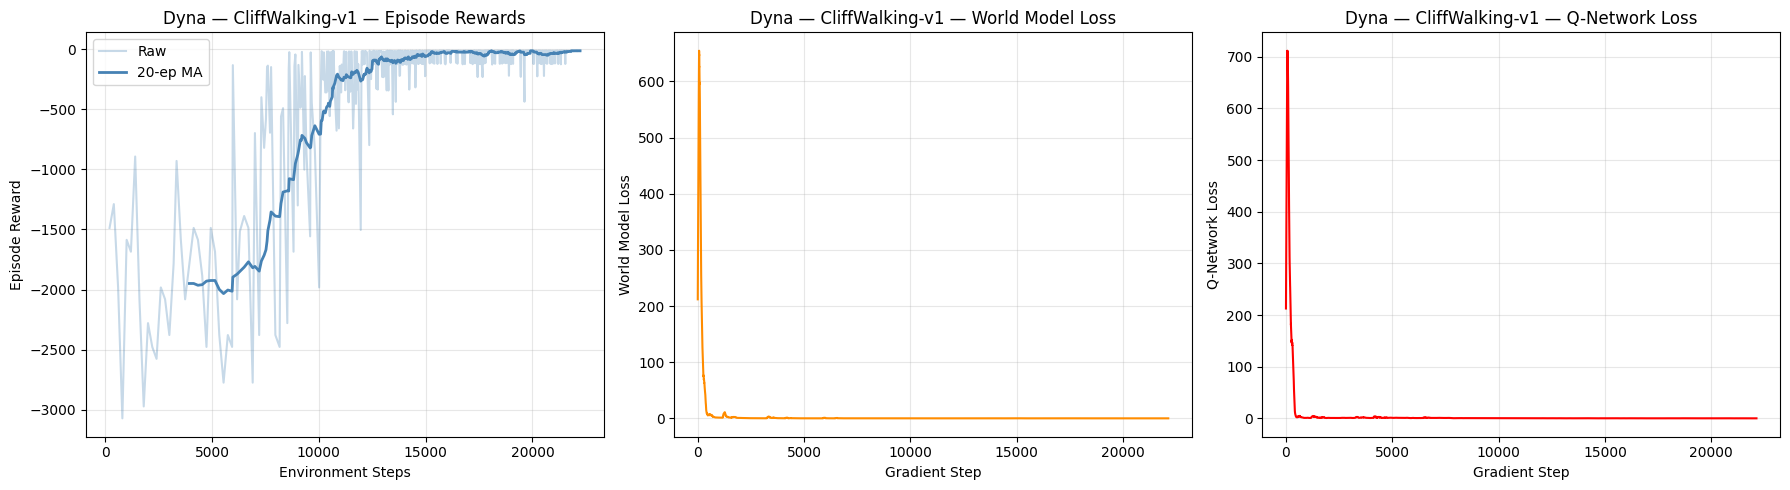

Final avg reward (last 20 ep): -13.7


In [ ]:
#Dyna-Q with 10 planning steps ----------------------------------------
set_seed(42)

results_dyna = train_dyna(
    env_name        = ENV_NAME,
    total_timesteps = 50_000,
    planning_steps  = 10,
    seed            = 42,
    lr              = 1e-3,
    batch_size      = 64,
    solve_threshold = -14.0,
    log_interval    = 50,
)

plot_dyna_results(results_dyna, title='Dyna — CliffWalking-v1', experiments_dir=EXPERIMENTS_DIR)
print(f'Final avg reward (last 20 ep): {np.mean(results_dyna["episode_rewards"][-20:]):.1f}')

Step  7,935 | Episode   50 | Avg(50): -1354.6 | eps: 0.605
Step 10,946 | Episode  100 | Avg(50): -460.2 | eps: 0.366
Step 12,573 | Episode  150 | Avg(50): -206.8 | eps: 0.221
Step 13,684 | Episode  200 | Avg(50):  -99.4 | eps: 0.134
Step 14,464 | Episode  250 | Avg(50):  -41.3 | eps: 0.081
Step 15,211 | Episode  300 | Avg(50):  -28.8 | eps: 0.050
Step 15,974 | Episode  350 | Avg(50):  -33.1 | eps: 0.050
Step 16,722 | Episode  400 | Avg(50):  -28.8 | eps: 0.050
Step 17,459 | Episode  450 | Avg(50):  -38.5 | eps: 0.050
Step 18,180 | Episode  500 | Avg(50):  -22.3 | eps: 0.050
Step 18,951 | Episode  550 | Avg(50):  -33.2 | eps: 0.050
Step 19,664 | Episode  600 | Avg(50):  -22.2 | eps: 0.050
Step 20,409 | Episode  650 | Avg(50):  -36.7 | eps: 0.050
Step 21,179 | Episode  700 | Avg(50):  -39.2 | eps: 0.050
Step 21,928 | Episode  750 | Avg(50):  -32.8 | eps: 0.050
Step 22,653 | Episode  800 | Avg(50):  -30.3 | eps: 0.050
Step 23,350 | Episode  850 | Avg(50):  -19.9 | eps: 0.050
Step 24,110 |

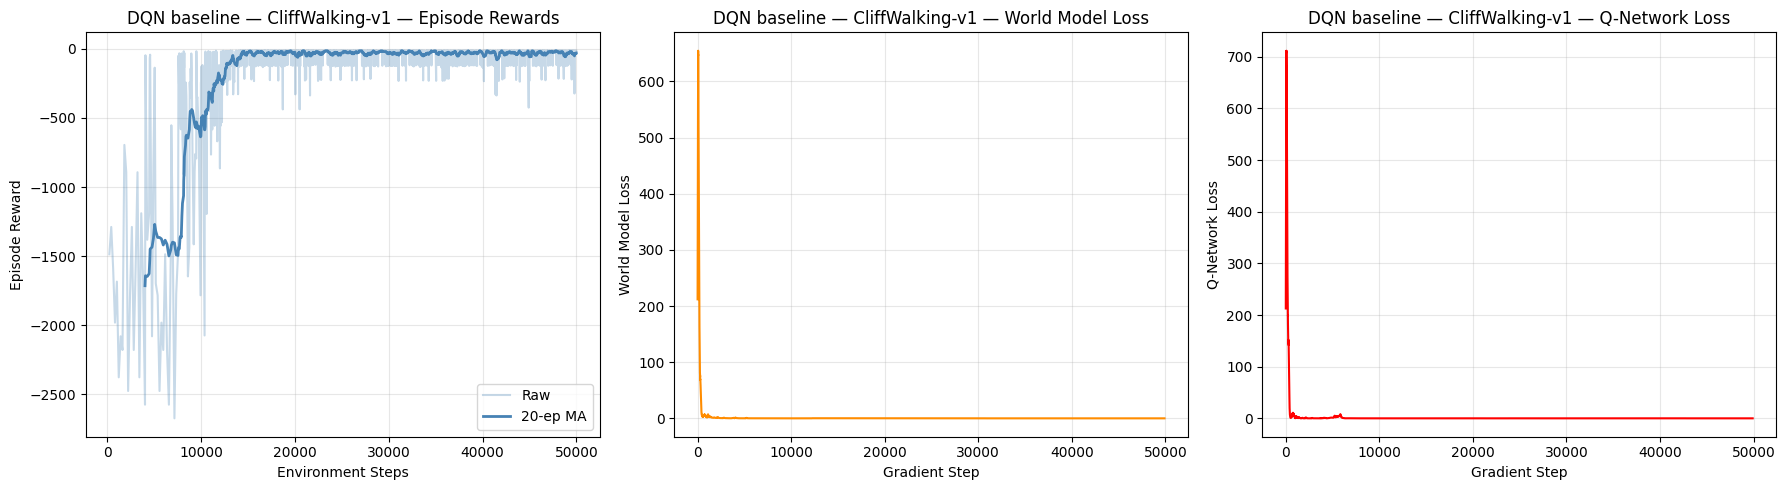

Final avg reward (last 20 ep): -29.3


In [52]:
#DQN baseline (0 planning steps) ----------------------------------------
set_seed(42)

results_dyna = train_dyna(
    env_name        = ENV_NAME,
    total_timesteps = 50_000,
    planning_steps  = 0,
    seed            = 42,
    lr              = 1e-3,
    batch_size      = 64,
    solve_threshold = -14.0,
    log_interval    = 50,
)

plot_dyna_results(results_dyna, title='DQN baseline — CliffWalking-v1', experiments_dir=EXPERIMENTS_DIR)
print(f'Final avg reward (last 20 ep): {np.mean(results_dyna["episode_rewards"][-20:]):.1f}')

## MCTS Planner

**Monte Carlo Tree Search (UCT)** plans by building a search tree from the current state. Each simulation:

1. **Selection** — traverse from root by UCB1 score until a leaf node
2. **Expansion** — add all unvisited children
3. **Simulation** — random rollout from the expanded node
4. **Backpropagation** — update visit counts and value estimates up to root

The action with the highest visit count at the root is returned.

We use `copy.deepcopy(env)` to fork the environment for each simulation — the real environment is never modified.

In [ ]:
class MCTSNode:
    """A single node in the MCTS tree — provided, no changes needed."""
    __slots__ = ('parent', 'action', 'children', 'visit_count', 'value_sum')

    def __init__(self, parent=None, action=None):
        self.parent      = parent
        self.action      = action
        self.children    = {}   # action_int -> MCTSNode
        self.visit_count = 0
        self.value_sum   = 0.0

    @property
    def q_value(self):
        return self.value_sum / self.visit_count if self.visit_count > 0 else 0.0

    def ucb(self, c=1.41):
        if self.visit_count == 0:
            return float('inf')
        return self.q_value + c * np.sqrt(np.log(self.parent.visit_count) / self.visit_count)

    def is_leaf(self):
        return len(self.children) == 0


class MCTSPlanner:
    """
    UCT planner using the true Gymnasium environment as a model.

    Uses copy.deepcopy(env) to fork the environment for each simulation.

    Args:
        action_dim    (int):   Number of discrete actions.
        n_simulations (int):   MCTS iterations per action selection.
        depth         (int):   Maximum rollout depth per simulation.
        gamma         (float): Discount factor for rollout returns.
        c             (float): UCB exploration constant.
    """

    def __init__(self, action_dim, n_simulations=50, depth=30, gamma=1.0, c=1.41):
        self.action_dim    = action_dim
        self.n_simulations = n_simulations
        self.depth         = depth
        self.gamma         = gamma
        self.c             = c

    def select_action(self, env):
        """
        Run MCTS from the current env state and return the best action.

        Args:
            env: current Gymnasium env (deepcopied internally — not modified).

        Returns:
            int: action with highest visit count at root.
        """
        root = MCTSNode()

        for _ in range(self.n_simulations):
            node = root
            sim_env = copy.deepcopy(env)
            terminated = False
            truncated = False

            #Track (parent_node, transition_reward) going down the tree for backpropagation
            visited: list[tuple[MCTSNode, float]] = []

            #Selection: traverse the tree using UCB until a leaf is reached.
            while not node.is_leaf() and not (terminated or truncated):
                
                #Find best action according to UCB
                best_action = None
                best_ucb = -float('inf')
                for a in node.children:
                    ucb_value = node.children[a].ucb(self.c) 
                    if ucb_value > best_ucb:
                        best_ucb = ucb_value
                        best_action = a
                
                #Step simulation and record parent before moving down
                _, reward, terminated, truncated, _ = sim_env.step(best_action)
                visited.append((node, reward))
                node = node.children[best_action]

            #Expansion: add children for all actions at the leaf.
            if not (terminated or truncated):
                for action in range(self.action_dim):
                    node.children[action] = MCTSNode(parent=node, action=action)
                    
                chosen_action = np.random.randint(self.action_dim)
                _, reward, terminated, truncated, _ = sim_env.step(chosen_action)
                
                #Record parent before moving down
                visited.append((node, reward)) 
                node = node.children[chosen_action]

            #Simulation: random rollout from the expanded node up to self.depth.
            rollout_return = 0.0
            for i in range(self.depth):
                if terminated or truncated:
                    break
                action = np.random.randint(self.action_dim)
                _, reward, terminated, truncated, _ = sim_env.step(action)
                rollout_return += reward * (self.gamma ** i)

            #Backpropagation: update visit counts and value sums back to root.
            cum_return = rollout_return
            for parent_node, r in reversed(visited): #For each (parent_node, transition_reward) going back up the tree
                cum_return = r + self.gamma * cum_return
                node.visit_count += 1
                node.value_sum += cum_return
                node = parent_node #move up to parent

            #Update root
            node.visit_count += 1
            node.value_sum += cum_return

        #Return the action at root with the highest visit count.
        best_action = None
        most_visits = -1
        for a in root.children:
            if root.children[a].visit_count > most_visits:
                most_visits = root.children[a].visit_count
                best_action = a
                
        return best_action


print('MCTSNode and MCTSPlanner defined')

MCTSNode and MCTSPlanner defined


In [48]:
def evaluate_mcts(env_name=ENV_NAME, n_simulations=50, depth=30,
                  num_episodes=20, seed=0):
    """
    Evaluate an MCTSPlanner on a given environment.

    Args:
        env_name      (str): Gymnasium environment id.
        n_simulations (int): MCTS iterations per step.
        depth         (int): Rollout depth per simulation.
        num_episodes  (int): Number of evaluation episodes.
        seed          (int): Base random seed.

    Returns:
        list: Episode rewards.
    """
    env     = gym.make(env_name)
    planner = MCTSPlanner(env.action_space.n,
                          n_simulations=n_simulations, depth=depth)
    rewards = []

    for ep in range(num_episodes):
        obs, _ = env.reset(seed=seed + ep)
        ep_reward = 0.0
        for _ in range(500):
            action = planner.select_action(env)
            obs, r, term, trunc, _ = env.step(action)
            ep_reward += r
            if term or trunc:
                break
        rewards.append(ep_reward)
        print(f'Episode {ep+1:2d}/{num_episodes}: reward = {ep_reward:.1f}')

    env.close()
    print(f'\nMean +/- Std: {np.mean(rewards):.1f} +/- {np.std(rewards):.1f}')
    return rewards

print('evaluate_mcts defined')

evaluate_mcts defined


## A.3 — Evaluate MCTS on CliffWalking-v1

Run MCTS with `n_simulations=50` and `depth=30` for 20 episodes.
Note: MCTS does **not** learn — it plans from scratch at each step using the true env.

In [49]:
set_seed(42)
rewards_mcts = evaluate_mcts(
    env_name      = ENV_NAME,
    n_simulations = 50,
    depth         = 30,
    num_episodes  = 20,
    seed          = 0,
)

Episode  1/20: reward = -144.0
Episode  2/20: reward = -72.0
Episode  3/20: reward = -210.0
Episode  4/20: reward = -115.0
Episode  5/20: reward = -116.0
Episode  6/20: reward = -156.0
Episode  7/20: reward = -66.0
Episode  8/20: reward = -82.0
Episode  9/20: reward = -38.0
Episode 10/20: reward = -191.0
Episode 11/20: reward = -121.0
Episode 12/20: reward = -117.0
Episode 13/20: reward = -303.0
Episode 14/20: reward = -278.0
Episode 15/20: reward = -70.0
Episode 16/20: reward = -334.0
Episode 17/20: reward = -216.0
Episode 18/20: reward = -96.0
Episode 19/20: reward = -93.0
Episode 20/20: reward = -114.0

Mean +/- Std: -146.6 +/- 81.1


## B.1 — Ablation: Planning Steps in Dyna

Sweep `planning_steps` ∈ {0, 5, 20, 50}. `k=0` is the pure DQN baseline.
At what point does more planning stop helping (model error compounding)?

Step  7,935 | Episode   50 | Avg(50): -1354.6 | eps: 0.605
Step 10,946 | Episode  100 | Avg(50): -460.2 | eps: 0.366
Step 12,573 | Episode  150 | Avg(50): -206.8 | eps: 0.221
Step 13,684 | Episode  200 | Avg(50):  -99.4 | eps: 0.134
Step 14,464 | Episode  250 | Avg(50):  -41.3 | eps: 0.081
Step 15,211 | Episode  300 | Avg(50):  -28.8 | eps: 0.050
Step 15,974 | Episode  350 | Avg(50):  -33.1 | eps: 0.050
Step 16,722 | Episode  400 | Avg(50):  -28.8 | eps: 0.050
Step 17,459 | Episode  450 | Avg(50):  -38.5 | eps: 0.050
Step 18,180 | Episode  500 | Avg(50):  -22.3 | eps: 0.050
Step 18,951 | Episode  550 | Avg(50):  -33.2 | eps: 0.050
Step 19,664 | Episode  600 | Avg(50):  -22.2 | eps: 0.050
Step 20,409 | Episode  650 | Avg(50):  -36.7 | eps: 0.050
Step 21,179 | Episode  700 | Avg(50):  -39.2 | eps: 0.050
Step 21,928 | Episode  750 | Avg(50):  -32.8 | eps: 0.050
Step 22,653 | Episode  800 | Avg(50):  -30.3 | eps: 0.050
Step 23,350 | Episode  850 | Avg(50):  -19.9 | eps: 0.050
Step 24,110 |

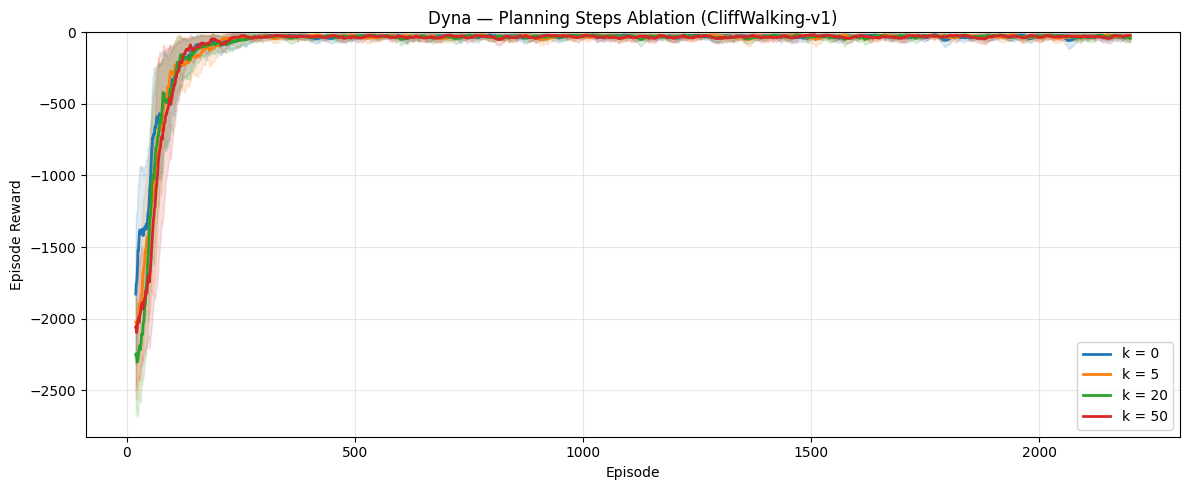

All lines shown over first 2200 episodes (limited by k=0 baseline).
Mean +/- Std (last 20 episodes):
  k = 0: -29.2 +/- 4.3
  k = 5: -35.4 +/- 4.3
  k = 20: -26.3 +/- 9.0
  k = 50: -22.4 +/- 6.8


In [22]:
seeds    = [42, 123, 456]
k_values = [0, 5, 20, 50]

ablation_results = {}
for k in k_values:
    ablation_results[f'k = {k}'] = [
        train_dyna(env_name=ENV_NAME, total_timesteps=50_000,
                   planning_steps=k, seed=s, lr=1e-3, batch_size=64,
                   solve_threshold=None)
        for s in seeds
    ]

# Use global min_eps so every k-value is plotted over the same episode range.
# (k=0 has fewest episodes; k=50 may have many more due to faster convergence.)
global_min_eps = min(
    min(len(r['episode_rewards']) for r in runs)
    for runs in ablation_results.values()
)

window  = 20
colors  = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, ax = plt.subplots(figsize=(12, 5))

for idx, (name, runs) in enumerate(ablation_results.items()):
    mat      = np.array([r['episode_rewards'][:global_min_eps] for r in runs])
    mean_r   = mat.mean(0)
    std_r    = mat.std(0)
    sm_mean  = smooth(mean_r, window)
    sm_std   = smooth(std_r,  window)
    episodes = np.arange(window, global_min_eps + 1)
    color    = colors[idx % len(colors)]
    ax.plot(episodes, sm_mean, color=color, label=name, linewidth=2)
    ax.fill_between(episodes, sm_mean - sm_std, sm_mean + sm_std,
                    color=color, alpha=0.15)

ax.set_xlabel('Episode')
ax.set_ylabel('Episode Reward')
ax.set_ylim(None, 0)
ax.set_title('Dyna — Planning Steps Ablation (CliffWalking-v1)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
_save_plot(fig, 'Dyna Planning Steps Ablation CliffWalking', EXPERIMENTS_DIR)
plt.show()

print(f'All lines shown over first {global_min_eps} episodes (limited by k=0 baseline).')
print('Mean +/- Std (last 20 episodes):')
for name, runs in ablation_results.items():
    final = [np.mean(r['episode_rewards'][-20:]) for r in runs]
    print(f'  {name}: {np.mean(final):.1f} +/- {np.std(final):.1f}')

## B.2 — MCTS: Effect of Simulation Count

Sweep `n_simulations` ∈ {5, 20, 50, 200}.
What is the minimum number of simulations needed to reliably find the safe path?

Episode  1/10: reward = -247.0
Episode  2/10: reward = -843.0
Episode  3/10: reward = -91.0
Episode  4/10: reward = -404.0
Episode  5/10: reward = -637.0
Episode  6/10: reward = -242.0
Episode  7/10: reward = -608.0
Episode  8/10: reward = -220.0
Episode  9/10: reward = -77.0
Episode 10/10: reward = -693.0

Mean +/- Std: -406.2 +/- 257.2
Episode  1/10: reward = -693.0
Episode  2/10: reward = -595.0
Episode  3/10: reward = -171.0
Episode  4/10: reward = -1534.0
Episode  5/10: reward = -418.0
Episode  6/10: reward = -362.0
Episode  7/10: reward = -819.0
Episode  8/10: reward = -82.0
Episode  9/10: reward = -406.0
Episode 10/10: reward = -146.0

Mean +/- Std: -522.6 +/- 406.8
Episode  1/10: reward = -373.0
Episode  2/10: reward = -1362.0
Episode  3/10: reward = -1094.0
Episode  4/10: reward = -484.0
Episode  5/10: reward = -105.0
Episode  6/10: reward = -195.0
Episode  7/10: reward = -567.0
Episode  8/10: reward = -551.0
Episode  9/10: reward = -72.0
Episode 10/10: reward = -702.0

Mean +

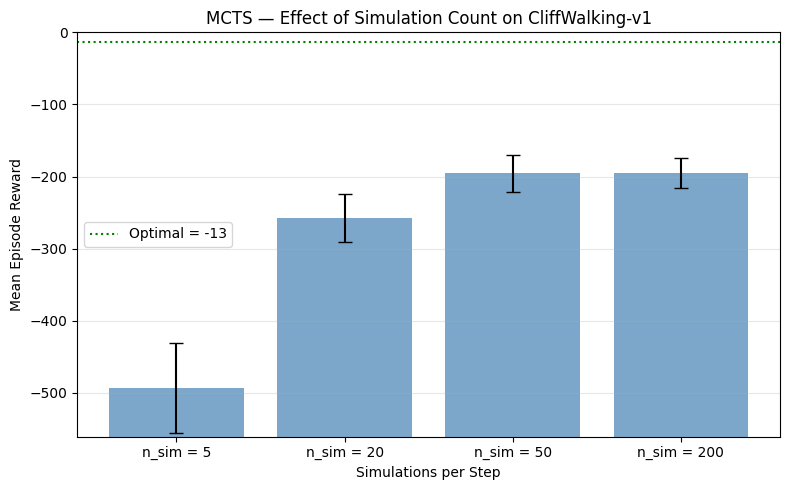

Mean +/- Std episode reward by simulation count:
  n_sim = 5: -493.1 +/- 62.5
  n_sim = 20: -257.3 +/- 33.1
  n_sim = 50: -195.4 +/- 25.6
  n_sim = 200: -195.3 +/- 20.6


In [50]:
sim_counts = [5, 20, 50, 200]
seeds_mcts = [0, 1, 2]

mcts_results = {}
for n in sim_counts:
    episode_lists = []
    for s in seeds_mcts:
        ep_rewards = evaluate_mcts(
            env_name      = ENV_NAME,
            n_simulations = n,
            depth         = 30,
            num_episodes  = 10,
            seed          = s * 100,
        )
        episode_lists.append(ep_rewards)
    mcts_results[f'n_sim = {n}'] = episode_lists

labels = list(mcts_results.keys())
means  = [np.mean([np.mean(ep) for ep in runs]) for runs in mcts_results.values()]
stds   = [np.std( [np.mean(ep) for ep in runs]) for runs in mcts_results.values()]

# Anchor bars below the worst value so they grow upward:
# taller bar = closer to 0 = better performance.
y_bot   = min(m - s for m, s in zip(means, stds)) - 5
heights = [m - y_bot for m in means]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(labels, heights, bottom=y_bot, yerr=stds, capsize=5,
       color='steelblue', alpha=0.7)
ax.axhline(-13, color='green', linestyle=':', label='Optimal = -13')
ax.set_ylim(y_bot, 0)
ax.set_ylabel('Mean Episode Reward')
ax.set_xlabel('Simulations per Step')
ax.set_title('MCTS — Effect of Simulation Count on CliffWalking-v1')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
_save_plot(fig, 'MCTS Simulation Count CliffWalking', EXPERIMENTS_DIR)
plt.show()

print('Mean +/- Std episode reward by simulation count:')
for k, (m, s) in zip(labels, zip(means, stds)):
    print(f'  {k}: {m:.1f} +/- {s:.1f}')

---

## Summary

**TODO:** Write a brief summary of your findings (double-click to edit).

1. **A.2 — Dyna-Q on CliffWalking-v1:** Describe the training dynamics — how does the WorldModel loss evolve? How quickly does DynaAgent converge compared to the pure DQN baseline (k=0)? What role does the planning loop play?

The WorldModel loss spikes early, but then drops fast and remains close to 0. Compared to pure DQN baseline, the DynaAgent converges slightly faster at ~12 000 environment steps while DQN baseline converges around ~15 000 environment steps. Both get good results in the end, but Dyna-Q with its average reward -13.7 is much more close to the optimal reward -13 than DQN baseline with -29.3 average reward. The faster convergence for Dyna-Q is because every real timestep the model is also trained with simulated transitions predicted from the WorldModel, which means it gets more training data to learn from. When it comes to average reward I think DQN baseline learns a worse policy because it can only learn from real experiences. This might lead to that the DQN_Agent only manages to find a slight detour far away from the cliff because it's scared of getting that big penalty. Dyna-Q on the other hand can train on its synthetic data meaning that if it only tried to walk the optimal path a few times, it can still train on simulations of the optimal path in order to learn it. 

2. **A.3 — MCTS on CliffWalking-v1:** Describe MCTS performance across the 20 evaluation episodes. What are its strengths and limitations compared to Dyna-Q?

The mean reward was ~-146 in comparison to the optimal reward -13, so on average our agent takes ~134 steps too much beyond optimal. The variance was ~81 and we can clearly see in printing of each episode that some episodes solves the problem somewhat cleanly, while other episodes results in that the agent walks off the cliff several times. This shows that MCTS is inconsistent, which seems reasonable due to that MCTS actually doesn't learn anything compared to the other models we've worked with in this course.

Strengths vs Dyna-Q is that training is not needed. This means that episode 1 of MCTS gives better results than episode 1 in Dyna-Q. It also doesn't need a replay buffer or a neural network so the complexity is much lower. One limitations that MCTS has compared to Dyna-Q is that MCTS doesn't really learn anything, because of how it builds its search tree from scratch every time. This means that it doesn't get better over time unlike Dyna-Q. Once Dyna-Q has been trained sufficiently enough it achieves close to perfect results whereas the MCTS mean isn't even close to optimal.

3. **B.1 — Planning steps ablation:** Which k value performed best? At what point does more planning stop helping, and why?

k = 50 performed the best with an average reward of -22.4 while k = 5 performed the worst. Only having a few planning steps like 5 actually made the model worse. I would think this is because the simulated transitions in the planning loop have some noise because they're predicted by the WorldModel. If we don't have enough simulated transitions we might have outliers or biased errors, which average out when we have more iterations of our planning loop. Overall we got better results with more planning, but the improvement was very small in comparison to the much higher computation cost. One reason that we get better results with planning here might also be that world model was very accurate for this environment. With more complex environments the world model might not be as accurate, and then a higher k value might actually decrease performance.

4. **B.2 — MCTS simulation count:** What is the minimum number of simulations needed to reliably find the safe path? Describe the performance vs. compute cost trade-off.

The result we got here was that using only 5 simulations doesn't work at all, and that we could probably get better results with random walking. Performance was then increased when increasing the n number of simulations up until somewhere around n = 50. There was only a very small performance improvement between 50 and 200 simulations while the computation cost is ~4 times higher. I imagine this might be because we use random rollouts, and that we would get better results if exchange random rollouts for controlled rollouts using a policy or some other type of technique. Regarding the performance vs compute cost trade-off it's definitely better to go with 50 simulations here than 200 because of how much higher the performance cost is. We could even test lower values for n like 30-45 in order to find one that has nearly the same performance as n = 50 but with lower computation cost. 

---

**Lab designed by Amath Sow:** [amath.sow@liu.se](mailto:amath.sow@liu.se)

**TDDE78 — Deep Reinforcement Learning, Linköping University — Spring 2026**